# Install

In [ ]:
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn
# !pip install scipy
# !pip install sklearn


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

# Importing libraries


In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker 
# import math
# import glob
# import seaborn as sns
# from scipy.stats import linregress
# from sklearn.model_selection import train_test_split


ModuleNotFoundError: No module named 'sklearn'

# Read the dataset 

In [4]:
main_df = pd.DataFrame()
for year in range(1995, 2000):
    file_pattern = f"{year}.csv"
    file_paths = glob.glob(file_pattern)
    year_data = pd.concat((pd.read_csv(file_path) for file_path in file_paths), ignore_index=True)
    #Cleaning the data 
    year_data = year_data.drop_duplicates()
    year_data = year_data[(year_data['ActualElapsedTime'] >= 0) | (year_data['ActualElapsedTime'].isna())] 
    year_data = year_data[(year_data['CRSElapsedTime'] >= 0) | (year_data['CRSElapsedTime'].isna())]
    year_data = year_data[(year_data['DepTime'] <= 2359) | (year_data['DepTime'].isna())]
    year_data = year_data[(year_data['ArrTime'] <= 2359) | (year_data['ArrTime'].isna())] #filters for times = 0 or na
    main_df = pd.concat([main_df, year_data], ignore_index=True)

print(main_df.head())

   Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime  ArrTime  \
0  1995      1           6          5    657.0         645    952.0   
1  1995      1           7          6    648.0         645    938.0   
2  1995      1           8          7    649.0         645    932.0   
3  1995      1           9          1    645.0         645    928.0   
4  1995      1          10          2    645.0         645    931.0   

   CRSArrTime UniqueCarrier  FlightNum  ... TaxiIn  TaxiOut  Cancelled  \
0         937            UA        482  ...      7       25          0   
1         937            UA        482  ...      5       17          0   
2         937            UA        482  ...      3       17          0   
3         937            UA        482  ...      3       16          0   
4         937            UA        482  ...      6       18          0   

   CancellationCode  Diverted  CarrierDelay WeatherDelay NASDelay  \
0               NaN         0           NaN          NaN   

In [6]:
# to show maain_df columns
print(main_df.columns)

Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime',
       'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum',
       'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay',
       'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')


# Creating delay_df for part (a)

In [20]:
#Dropping unused columns     
delay_df = main_df.drop(columns=['AirTime', 'CancellationCode', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'LateAircraftDelay', 'SecurityDelay', 'FlightNum', 'Origin', 'Dest', 'TaxiIn', 'TaxiOut', 'Cancelled', 'TailNum','UniqueCarrier'])

print(delay_df)

          Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime  ArrTime  \
0         1995      1           6          5    657.0         645    952.0   
1         1995      1           7          6    648.0         645    938.0   
2         1995      1           8          7    649.0         645    932.0   
3         1995      1           9          1    645.0         645    928.0   
4         1995      1          10          2    645.0         645    931.0   
...        ...    ...         ...        ...      ...         ...      ...   
26992102  1999     12          16          4   1910.0        1910   2112.0   
26992103  1999     12          17          5   1909.0        1910   2111.0   
26992104  1999     12          18          6   1907.0        1910   2103.0   
26992105  1999     12          19          7   1907.0        1910   2114.0   
26992106  1999     12          20          1   1905.0        1910   2127.0   

          CRSArrTime  ActualElapsedTime  CRSElapsedTime  ArrDel

Removing null values

In [21]:

# delay_df.dropna(inplace=True)

Checking for null values

In [22]:
print(delay_df.isnull().sum())


Year                      0
Month                     0
DayofMonth                0
DayOfWeek                 0
DepTime              617022
CRSDepTime                0
ArrTime              680419
CRSArrTime                0
ActualElapsedTime    680419
CRSElapsedTime        24122
ArrDelay             680419
DepDelay             617022
Distance               5984
Diverted                  0
dtype: int64


In [23]:
delay_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26992107 entries, 0 to 26992106
Data columns (total 14 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Year               int64  
 1   Month              int64  
 2   DayofMonth         int64  
 3   DayOfWeek          int64  
 4   DepTime            float64
 5   CRSDepTime         int64  
 6   ArrTime            float64
 7   CRSArrTime         int64  
 8   ActualElapsedTime  float64
 9   CRSElapsedTime     float64
 10  ArrDelay           float64
 11  DepDelay           float64
 12  Distance           float64
 13  Diverted           int64  
dtypes: float64(7), int64(7)
memory usage: 2.8 GB


In [24]:
delay_df.describe()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,ActualElapsedTime,CRSElapsedTime,ArrDelay,DepDelay,Distance,Diverted
count,2.699211e+07,2.699211e+07,2.699211e+07,2.699211e+07,2.637508e+07,2.699211e+07,2.631169e+07,2.699211e+07,2.631169e+07,2.696798e+07,2.631169e+07,2.637508e+07,2.698612e+07,2.699211e+07
mean,1.997016e+03,6.521392e+00,1.571504e+01,3.941119e+00,1.353681e+03,1.313714e+03,1.497183e+03,1.465750e+03,1.215364e+02,1.222614e+02,7.992246e+00,8.962362e+00,7.249617e+02,2.348724e-03
std,1.416093e+00,3.440587e+00,8.783788e+00,1.990095e+00,4.798065e+02,5.079782e+02,5.021760e+02,5.310723e+02,6.805769e+01,6.764184e+01,2.989306e+01,2.930411e+01,5.476281e+02,4.840669e-02
min,1.995000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.426000e+03,-9.180000e+02,1.100000e+01,0.000000e+00
25%,1.996000e+03,4.000000e+00,8.000000e+00,2.000000e+00,9.350000e+02,9.150000e+02,1.118000e+03,1.104000e+03,7.100000e+01,7.100000e+01,-6.000000e+00,-1.000000e+00,3.280000e+02,0.000000e+00
50%,1.997000e+03,7.000000e+00,1.600000e+01,4.000000e+00,1.338000e+03,1.323000e+03,1.526000e+03,1.515000e+03,1.030000e+02,1.040000e+02,1.000000e+00,0.000000e+00,5.740000e+02,0.000000e+00
75%,1.998000e+03,1.000000e+01,2.300000e+01,6.000000e+00,1.741000e+03,1.725000e+03,1.922000e+03,1.914000e+03,1.530000e+02,1.540000e+02,1.200000e+01,7.000000e+00,9.570000e+02,0.000000e+00
max,1.999000e+03,1.200000e+01,3.100000e+01,7.000000e+00,2.359000e+03,2.400000e+03,2.359000e+03,2.400000e+03,1.771000e+03,1.592000e+03,1.808000e+03,1.800000e+03,4.962000e+03,1.000000e+00


# Finding delays 

## Delay classification 

According to the United States Federal Aviation Administration (FAA), an aircraft is considered delayed when it is 15 minutes late than its scheduled time. Cancelled flights would classify as an anomaly and thus the data points with cancelled flights will be omitted in this particular analysis. The scheduled departure time is used as it is what travelers will be looking at when booking flights, thus, if we want to analyse delays and such we analyse form a traveler point of view.

Ontime: less than 15mins

mild delay: 15mins to 60mins 

moderate delay: 60 mins to 180mins 

severe delay: more than 180mins 




## Time of day classification 

Midnight: 0000 to 0559

Morning: 0600 to 1159

Afternoon: 1200 to 1759

Night: 1800 to 2359 

# Adding column for Time_of_Day and Degree_of_Delay

In [25]:
# Creating a function for the delay time
def delay_classification(time):
    if pd.isna(time):
        return None
    elif time <= 15:
        return 'On Time'
    elif time < 60:
        return 'Mild delay'
    elif time < 180:
        return 'Moderate Delay'
    else:
        return 'Severe Delayed'


# Creating a function for time of day classification
def time_of_day(time):
    if time <= 559:
        return 'Midnight'
    elif time <= 1159:
        return 'Morning'
    elif time <= 1759:
        return 'Afternoon'
    else:
        return 'Evening'
    
#creating a new column 'Delay Classification' and 'Time of Day'
delay_df['Delay_Classification'] = delay_df['ArrDelay'].apply(delay_classification)
delay_df['Time_of_Day'] = delay_df['CRSDepTime'].apply(time_of_day)

print(delay_df)

          Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime  ArrTime  \
0         1995      1           6          5    657.0         645    952.0   
1         1995      1           7          6    648.0         645    938.0   
2         1995      1           8          7    649.0         645    932.0   
3         1995      1           9          1    645.0         645    928.0   
4         1995      1          10          2    645.0         645    931.0   
...        ...    ...         ...        ...      ...         ...      ...   
26992102  1999     12          16          4   1910.0        1910   2112.0   
26992103  1999     12          17          5   1909.0        1910   2111.0   
26992104  1999     12          18          6   1907.0        1910   2103.0   
26992105  1999     12          19          7   1907.0        1910   2114.0   
26992106  1999     12          20          1   1905.0        1910   2127.0   

          CRSArrTime  ActualElapsedTime  CRSElapsedTime  ArrDel

## Converting "Day of week" and "Month" into name (string) 

In [26]:
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

delay_df['DayOfWeekString'] = delay_df['DayOfWeek'].apply(lambda day: days[day - 1]) #applies the lambda function which takes in dayofweek column and compares it to day order, -1 as python index starts from 0, therefore monday = 1 would be =0 in days_order
delay_df['MonthString'] = delay_df['Month'].apply(lambda month: months[month - 1]) #similar to above explaination but months

#Finalised main data frame
print(delay_df.head())

   Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime  ArrTime  \
0  1995      1           6          5    657.0         645    952.0   
1  1995      1           7          6    648.0         645    938.0   
2  1995      1           8          7    649.0         645    932.0   
3  1995      1           9          1    645.0         645    928.0   
4  1995      1          10          2    645.0         645    931.0   

   CRSArrTime  ActualElapsedTime  CRSElapsedTime  ArrDelay  DepDelay  \
0         937              115.0           112.0      15.0      12.0   
1         937              110.0           112.0       1.0       3.0   
2         937              103.0           112.0      -5.0       4.0   
3         937              103.0           112.0      -9.0       0.0   
4         937              106.0           112.0      -6.0       0.0   

   Distance  Diverted Delay_Classification Time_of_Day DayOfWeekString  \
0     678.0         0              On Time     Morning          Fr

## Create new Dataframe for 2(a) and remove empty or NaN values in 'Delay Classification'

In [27]:
final_delay_df = delay_df.dropna(subset=['Delay_Classification'])

In [28]:
# check for null values for Delay Classification
print(delay_df.isnull().sum())

Year                         0
Month                        0
DayofMonth                   0
DayOfWeek                    0
DepTime                 617022
CRSDepTime                   0
ArrTime                 680419
CRSArrTime                   0
ActualElapsedTime       680419
CRSElapsedTime           24122
ArrDelay                680419
DepDelay                617022
Distance                  5984
Diverted                     0
Delay_Classification    680419
Time_of_Day                  0
DayOfWeekString              0
MonthString                  0
dtype: int64


In [29]:
print(final_delay_df.isnull().sum())

Year                       0
Month                      0
DayofMonth                 0
DayOfWeek                  0
DepTime                    0
CRSDepTime                 0
ArrTime                    0
CRSArrTime                 0
ActualElapsedTime          0
CRSElapsedTime             0
ArrDelay                   0
DepDelay                   0
Distance                5895
Diverted                   0
Delay_Classification       0
Time_of_Day                0
DayOfWeekString            0
MonthString                0
dtype: int64


## Group the delays by 'Time of day' and 'Delay Classification'

In [30]:
final_delay_df = final_delay_df.value_counts(['Time_of_Day', 'Delay_Classification']).reset_index(name='count')


In [31]:
print(final_delay_df)

   Time_of_Day Delay_Classification    count
0      Morning              On Time  8480554
1    Afternoon              On Time  7632276
2      Evening              On Time  4227760
3    Afternoon           Mild delay  1653920
4      Morning           Mild delay  1188267
5      Evening           Mild delay  1090513
6     Midnight              On Time   679672
7    Afternoon       Moderate Delay   462776
8      Evening       Moderate Delay   381919
9      Morning       Moderate Delay   234631
10    Midnight           Mild delay   123669
11   Afternoon       Severe Delayed    50259
12    Midnight       Moderate Delay    40505
13     Evening       Severe Delayed    36375
14     Morning       Severe Delayed    23656
15    Midnight       Severe Delayed     4936


In [32]:
print(delay_df['Delay_Classification'].value_counts()) # checking against main_df

Delay_Classification
On Time           21020262
Mild delay         4056369
Moderate Delay     1119831
Severe Delayed      115226
Name: count, dtype: int64


In [33]:
# Calculate total flights for each 'Time_of_Day'
total_per_time_of_day = final_delay_df.groupby('Time_of_Day')['count'].transform('sum')

# Compute weighted percentage for each row
final_delay_df['Weighted_Percentage'] = (final_delay_df['count'] / total_per_time_of_day) * 100

# Round to 2 decimal places for readability
final_delay_df['Weighted_Percentage'] = final_delay_df['Weighted_Percentage'].round(2)

# Display the result
print(final_delay_df)


   Time_of_Day Delay_Classification    count  Weighted_Percentage
0      Morning              On Time  8480554                85.43
1    Afternoon              On Time  7632276                77.89
2      Evening              On Time  4227760                73.70
3    Afternoon           Mild delay  1653920                16.88
4      Morning           Mild delay  1188267                11.97
5      Evening           Mild delay  1090513                19.01
6     Midnight              On Time   679672                80.08
7    Afternoon       Moderate Delay   462776                 4.72
8      Evening       Moderate Delay   381919                 6.66
9      Morning       Moderate Delay   234631                 2.36
10    Midnight           Mild delay   123669                14.57
11   Afternoon       Severe Delayed    50259                 0.51
12    Midnight       Moderate Delay    40505                 4.77
13     Evening       Severe Delayed    36375                 0.63
14     Mor

In [34]:
#Finding average delay for the year based on time of day

#data frame for each year
year_delay_df = delay_df.groupby(['Year', 'Time_of_Day'])['ArrDelay'].mean().reset_index()
# rename 
year_delay_df.rename(columns={'ArrDelay': 'Average_Delay'}, inplace=True)

print(year_delay_df)

    Year Time_of_Day  Average_Delay
0   1995   Afternoon       8.002097
1   1995     Evening      10.740020
2   1995    Midnight       9.417104
3   1995     Morning       3.720031
4   1996   Afternoon      10.778365
5   1996     Evening      14.578971
6   1996    Midnight      10.647965
7   1996     Morning       5.661108
8   1997   Afternoon       8.602384
9   1997     Evening      11.334158
10  1997    Midnight       7.504000
11  1997     Morning       4.145050
12  1998   Afternoon       9.037449
13  1998     Evening      12.375852
14  1998    Midnight       2.893504
15  1998     Morning       3.676870
16  1999   Afternoon      10.563829
17  1999     Evening      12.795380
18  1999    Midnight       6.465170
19  1999     Morning       3.548601


# 2(a) Finding the best time to fly through visualization 

visualiZation for Average delay for time of day throughout the years

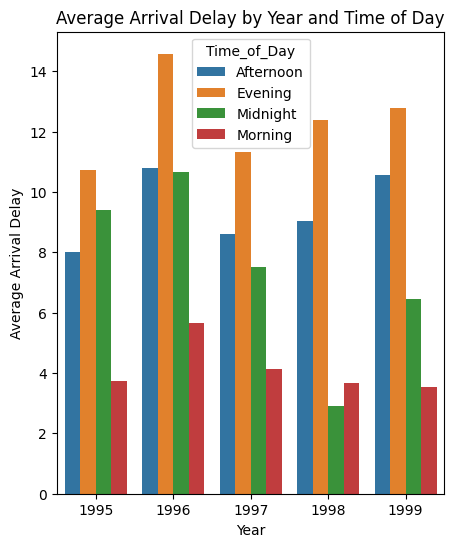

In [35]:
 
# Plotting bar graph for the average delay for the year based on time of day
plt.figure(figsize=(5, 6))
sns.barplot(data=year_delay_df,
            x='Year',
            y='Average_Delay',
            hue='Time_of_Day',
            dodge=True,)

# Set plot labels and title
plt.title("Average Arrival Delay by Year and Time of Day")
plt.xlabel("Year")
plt.ylabel("Average Arrival Delay")

plt.show()


Axes(0.125,0.11;0.775x0.77)


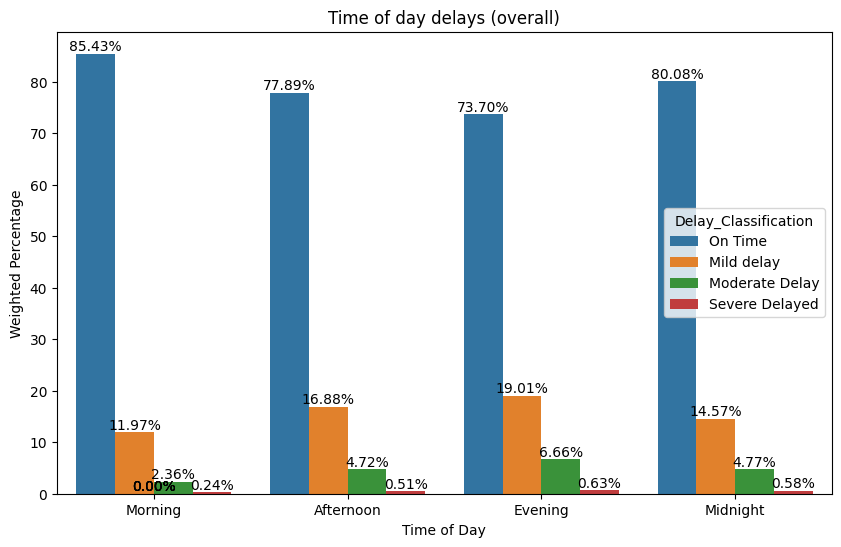

In [36]:
plt.figure(figsize=(10, 6))
tod_overall_g = sns.barplot(data=final_delay_df,
                            x='Time_of_Day',
                            y='Weighted_Percentage',
                            hue='Delay_Classification',
                            dodge=True,) #dodge to unstack bar

# percentage labels for each bar and legend
for b in tod_overall_g.patches:
    tod_overall_g.annotate(
        f'{b.get_height():.2f}%', # indicates the text anotations and the format being a string with 2 decimal places and % attached to the string
        (b.get_x() + b.get_width() / 2., b.get_height()),
        ha='center',
        va='center',
        xytext=(0, 5),
        textcoords='offset points',
        size=10,) 

# labels and title
plt.title("Time of day delays (overall)")
plt.xlabel("Time of Day")
plt.ylabel("Weighted Percentage")
print(tod_overall_g)

Finding which time of day is the best to travel

In [37]:
# Define the custom sort order for Time_of_Day
time_order = ["Morning", "Afternoon", "Evening", "Midnight"]

# Ensure Time_of_Day is categorical and ordered
final_delay_df['Time_of_Day'] = pd.Categorical(final_delay_df['Time_of_Day'], categories=time_order, ordered=True)

# Grouping: "On Time" separate, all delays combined
time_df = final_delay_df.copy()
time_df['Delay_Classification'] = time_df['Delay_Classification'].apply(lambda x: 'Delayed' if x != 'On Time' else 'On Time')

# Aggregate counts
time_df = time_df.groupby(['Time_of_Day', 'Delay_Classification'], as_index=False).agg(
    count=('count', 'sum')
)

# Calculate total count across all rows
total_count = time_df['count'].sum()

# Recalculate weighted percentage based on total count
time_df['Weighted_Percentage'] = (time_df['count'] / total_count) * 100

# Sort by Time_of_Day
time_df = time_df.sort_values('Time_of_Day')

# Round to 2 dp for better readability
time_df['Weighted_Percentage'] = time_df['Weighted_Percentage'].round(2)

# Display the final grouped DataFrame
print(time_df)


  Time_of_Day Delay_Classification    count  Weighted_Percentage
0     Morning              Delayed  1446554                 5.50
1     Morning              On Time  8480554                32.23
2   Afternoon              Delayed  2166955                 8.24
3   Afternoon              On Time  7632276                29.01
4     Evening              Delayed  1508807                 5.73
5     Evening              On Time  4227760                16.07
6    Midnight              Delayed   169110                 0.64
7    Midnight              On Time   679672                 2.58


C:\Users\thund\AppData\Local\Temp\ipykernel_19860\2274452265.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_df = time_df.groupby(['Time_of_Day', 'Delay_Classification'], as_index=False).agg(


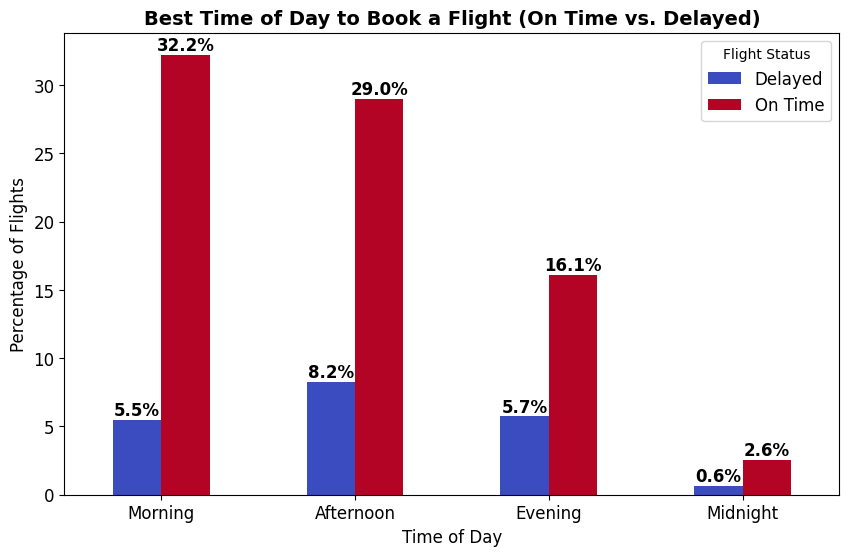

In [38]:


# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Pivot the DataFrame for plotting
grouped_pivot = time_df.pivot(index="Time_of_Day", columns="Delay_Classification", values="Weighted_Percentage")

# Plot stacked bar chart
grouped_pivot.plot(kind="bar", stacked=False, colormap="coolwarm", ax=ax)

# Add numerical values on the bars
for i, bars in enumerate(ax.containers):
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Avoid placing labels on 0 values
            ax.text(
                bar.get_x() + bar.get_width() / 2,  # X position
                bar.get_y() + height + 0.7 ,  # Y position 
                f"{height:.1f}%",  # Format as percentage
                ha="center",
                va="center",
                fontsize=12,
                color="black",
                fontweight="bold"
            )

# Labels and title
plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Percentage of Flights", fontsize=12)
plt.title("Best Time of Day to Book a Flight (On Time vs. Delayed)", fontsize=14, fontweight="bold")
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Flight Status", fontsize=12)

# Show the plot
plt.show()




Booking a morning flight is the best time of the day. It has the highest percentage of flights that are on time at 32.2%. 

# Finding the best day of the week to book flight tickets

In [39]:
delay_df.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,ActualElapsedTime,CRSElapsedTime,ArrDelay,DepDelay,Distance,Diverted,Delay_Classification,Time_of_Day,DayOfWeekString,MonthString
0,1995,1,6,5,657.0,645,952.0,937,115.0,112.0,15.0,12.0,678.0,0,On Time,Morning,Friday,January
1,1995,1,7,6,648.0,645,938.0,937,110.0,112.0,1.0,3.0,678.0,0,On Time,Morning,Saturday,January
2,1995,1,8,7,649.0,645,932.0,937,103.0,112.0,-5.0,4.0,678.0,0,On Time,Morning,Sunday,January
3,1995,1,9,1,645.0,645,928.0,937,103.0,112.0,-9.0,0.0,678.0,0,On Time,Morning,Monday,January
4,1995,1,10,2,645.0,645,931.0,937,106.0,112.0,-6.0,0.0,678.0,0,On Time,Morning,Tuesday,January


Taking out the necessary columns

In [46]:
day_df = delay_df[[ 'DayOfWeekString', 'Delay_Classification']]
print(day_df)


         DayOfWeekString Delay_Classification
0                 Friday              On Time
1               Saturday              On Time
2                 Sunday              On Time
3                 Monday              On Time
4                Tuesday              On Time
...                  ...                  ...
26992102        Thursday              On Time
26992103          Friday              On Time
26992104        Saturday              On Time
26992105          Sunday              On Time
26992106          Monday              On Time

[26992107 rows x 2 columns]


In [ ]:

day_df['Delay_Classification'] = day_df['Delay_Classification'].apply(lambda x: 'Delayed' if x != 'On Time' else 'On Time')

# Step 2: Count occurrences of "On Time" and "Delayed" for each day
grouped_day_df = day_df.groupby(['DayOfWeekString', 'Delay_Classification'], as_index=False).size()

# Step 3: Rename column for clarity
grouped_day_df.rename(columns={'size': 'Count'}, inplace=True)

# Step 4: Calculate total flights for each day
grouped_day_df['TotalPerDay'] = grouped_day_df.groupby('DayOfWeekString')['Count'].transform('sum')

# Step 5: Calculate percentage of delayed flights for each day
grouped_day_df['Percentage'] = (grouped_day_df['Count'] / grouped_day_df['TotalPerDay']) * 100
grouped_day_df['Percentage'] = grouped_day_df['Percentage'].round(2)  # Round to 2 decimal places

# Step 6: Define custom order for sorting
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
grouped_day_df['DayOfWeekString'] = pd.Categorical(grouped_day_df['DayOfWeekString'], categories=days_order, ordered=True)

# Step 7: Sort by day of the week
grouped_day_df = grouped_day_df.sort_values('DayOfWeekString')

# Step 8: Display the result
print(grouped_day_df)





C:\Users\thund\AppData\Local\Temp\ipykernel_19860\2840724578.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_df['Delay_Classification'] = day_df['Delay_Classification'].apply(lambda x: 'Delayed' if x != 'On Time' else 'On Time')


   DayOfWeekString Delay_Classification    Count  TotalPerDay  Percentage
2           Monday              Delayed   834512      3953682       21.11
3           Monday              On Time  3119170      3953682       78.89
10         Tuesday              Delayed   826544      3962634       20.86
11         Tuesday              On Time  3136090      3962634       79.14
12       Wednesday              Delayed   886326      3959972       22.38
13       Wednesday              On Time  3073646      3959972       77.62
8         Thursday              Delayed   964292      3939893       24.48
9         Thursday              On Time  2975601      3939893       75.52
0           Friday              Delayed  1014283      3936197       25.77
1           Friday              On Time  2921914      3936197       74.23
4         Saturday              Delayed   661781      3498430       18.92
5         Saturday              On Time  2836649      3498430       81.08
6           Sunday              Delaye

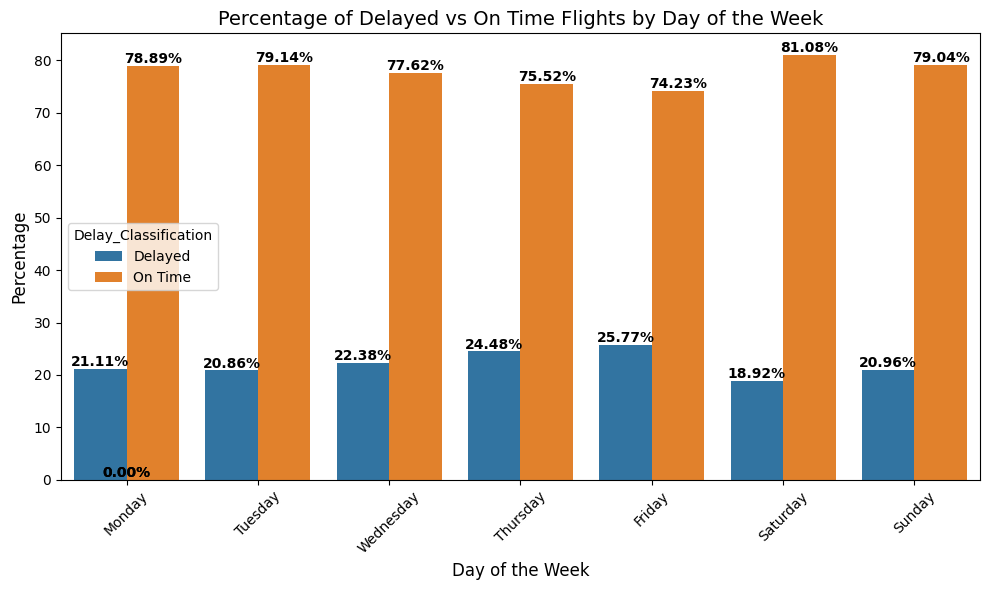

In [ ]:

# Assuming your DataFrame is called grouped_day_df
# Plotting the data
plt.figure(figsize=(10, 6))

# Create a bar plot
ax = sns.barplot(x='DayOfWeekString', y='Percentage', hue='Delay_Classification', data=grouped_day_df)

# Add title and labels
plt.title("Percentage of Delayed vs On Time Flights by Day of the Week", fontsize=14)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Percentage", fontsize=12)

# Add the percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=10,fontweight = 'bold', color='black', 
                xytext=(0, 5), textcoords='offset points')

# Display the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Tuesday has the highest percentage of on time flights at 11.62%.

# Part 2(b)

# Evaluate whether older planes suffer more delays on a year-to-year basis.

Based on google, a plane is considered "old" when it is over 20 years old

-cleaning planes dataset

In [50]:
planes_df = pd.read_csv('plane-data.csv')
print(planes_df)

     tailnum                 type                   manufacturer  issue_date  \
0     N050AA                  NaN                            NaN         NaN   
1     N051AA                  NaN                            NaN         NaN   
2     N052AA                  NaN                            NaN         NaN   
3     N054AA                  NaN                            NaN         NaN   
4     N055AA                  NaN                            NaN         NaN   
...      ...                  ...                            ...         ...   
5024  N997DL          Corporation  MCDONNELL DOUGLAS AIRCRAFT CO  03/11/1992   
5025  N998AT          Corporation                         BOEING  01/23/2003   
5026  N998DL          Corporation  MCDONNELL DOUGLAS CORPORATION  04/02/1992   
5027  N999CA  Foreign Corporation                       CANADAIR  07/09/2008   
5028  N999DN          Corporation  MCDONNELL DOUGLAS CORPORATION  04/02/1992   

            model status            air

In [51]:
print(planes_df.isnull().sum())

tailnum            0
type             549
manufacturer     549
issue_date       550
model            549
status           549
aircraft_type    549
engine_type      552
year             694
dtype: int64


In [52]:
print(planes_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5029 entries, 0 to 5028
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tailnum        5029 non-null   object 
 1   type           4480 non-null   object 
 2   manufacturer   4480 non-null   object 
 3   issue_date     4479 non-null   object 
 4   model          4480 non-null   object 
 5   status         4480 non-null   object 
 6   aircraft_type  4480 non-null   object 
 7   engine_type    4477 non-null   object 
 8   year           4335 non-null   float64
dtypes: float64(1), object(8)
memory usage: 353.7+ KB
None


In [54]:
main_df.columns = main_df.columns.str.lower()
planes_df.columns = planes_df.columns.str.lower()
planes_info_df = pd.merge(main_df, planes_df, how='inner', left_on='tailnum', right_on='tailnum', suffixes=('main_df', 'planes_df'))


In [55]:
print(planes_info_df)

         yearmain_df  month  dayofmonth  dayofweek  deptime  crsdeptime  \
0               1995      1           2          1   1148.0        1145   
1               1995      1           3          2   1209.0        1145   
2               1995      1           7          6   1200.0        1150   
3               1995      1           8          7   1151.0        1150   
4               1995      1           9          1   1154.0        1150   
...              ...    ...         ...        ...      ...         ...   
9748385         1999     12          12          7   1244.0        1246   
9748386         1999     12          13          1   1244.0        1246   
9748387         1999     12           1          3    940.0         941   
9748388         1999     12           5          7    937.0         943   
9748389         1999     12          12          7    940.0         943   

         arrtime  crsarrtime uniquecarrier  flightnum  ... securitydelay  \
0         1428.0       

In [67]:
column_names = planes_info_df.columns.tolist()
print(column_names)

['yearmain_df', 'month', 'dayofmonth', 'dayofweek', 'deptime', 'crsdeptime', 'arrtime', 'crsarrtime', 'uniquecarrier', 'flightnum', 'tailnum', 'actualelapsedtime', 'crselapsedtime', 'airtime', 'arrdelay', 'depdelay', 'origin', 'dest', 'distance', 'taxiin', 'taxiout', 'cancelled', 'cancellationcode', 'diverted', 'carrierdelay', 'weatherdelay', 'nasdelay', 'securitydelay', 'lateaircraftdelay', 'type', 'manufacturer', 'issue_date', 'model', 'status', 'aircraft_type', 'engine_type', 'yearplanes_df', 'plane_age', 'total_delay']


In [68]:
plane_merged_df = planes_info_df[['yearmain_df','flightnum', 'tailnum','arrdelay', 'depdelay','yearplanes_df']]

In [69]:
print(plane_merged_df.head())

   yearmain_df  flightnum tailnum  arrdelay  depdelay  yearplanes_df
0         1995       1845  N929UA      -7.0       3.0         1992.0
1         1995       1845  N922UA      15.0      24.0         1991.0
2         1995       1845  N933UA       7.0      10.0         1992.0
3         1995       1845  N308UA      -5.0       1.0         1987.0
4         1995       1845  N913UA      -7.0       4.0         1991.0


Finding age of plane and total delay

In [87]:
# Assuming your DataFrame is called plane_merged_df
current_year = plane_merged_df['yearmain_df']

# Calculate the plane's age
plane_merged_df['plane_age'] = current_year - plane_merged_df['yearplanes_df']

# Calculate total delay (sum of arrival delay and departure delay) for each plane
plane_merged_df['average_total_delay'] = plane_merged_df['arrdelay'] + plane_merged_df['depdelay']

# Group by 'tailnum' to calculate average delays for each plane
plane_summary_df = plane_merged_df.groupby('tailnum').agg(
    average_arrdelay=('arrdelay', 'mean'),  # Calculate the average arrival delay
    average_depdelay=('depdelay', 'mean'),  # Calculate the average departure delay
    total_delay=('average_total_delay', 'mean'),  # Calculate the average total delay
    plane_age=('plane_age', 'first')  # Take the first plane's age as it will be the same for the plane
).reset_index()

print(plane_summary_df)




C:\Users\thund\AppData\Local\Temp\ipykernel_19860\3625008668.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plane_merged_df['plane_age'] = current_year - plane_merged_df['yearplanes_df']
C:\Users\thund\AppData\Local\Temp\ipykernel_19860\3625008668.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plane_merged_df['average_total_delay'] = plane_merged_df['arrdelay'] + plane_merged_df['depdelay']


     tailnum  average_arrdelay  average_depdelay  total_delay  plane_age
0     N050AA         13.218307         14.317297    27.466488        NaN
1     N051AA         13.433580         15.155970    28.363849        NaN
2     N052AA         13.265011         13.811760    27.078577        NaN
3     N054AA         13.110179         14.050171    27.170797        NaN
4     N055AA         10.596542         12.247126    22.807997        NaN
...      ...               ...               ...          ...        ...
1810  N995DL          6.947913          6.962039    13.886228        4.0
1811  N996DL          6.756909          7.797110    14.531397        4.0
1812  N997DL          7.192632          7.450579    14.611580        3.0
1813  N998DL          7.094456          6.928331    13.985273        3.0
1814  N999DN          7.604365          7.167715    14.754492        3.0

[1815 rows x 5 columns]


In [82]:
print(plane_summary_df.isnull().sum())

tailnum          0
total_delay      0
plane_age      225
dtype: int64


In [89]:
# remove NaN values for plane age
plane_summary_df.dropna(subset=['plane_age'], inplace=True)

In [84]:
print(plane_summary_df.isnull().sum())

tailnum        0
total_delay    0
plane_age      0
dtype: int64


Removing plane age with negative values

In [90]:
# Filter out rows where plane_age is negative
plane_summary_df = plane_summary_df[plane_summary_df['plane_age'] >= 0]

print(plane_summary_df)


     tailnum  average_arrdelay  average_depdelay  total_delay  plane_age
34    N102UW         10.036585          9.693657    19.757453        1.0
35    N10323          6.577956          7.088053    13.609401        9.0
36    N104UA         11.612069         12.758621    24.370690        0.0
37    N104UW         13.953317         12.506143    26.459459        0.0
38    N105UA         18.342037         20.792746    38.281984        1.0
...      ...               ...               ...          ...        ...
1810  N995DL          6.947913          6.962039    13.886228        4.0
1811  N996DL          6.756909          7.797110    14.531397        4.0
1812  N997DL          7.192632          7.450579    14.611580        3.0
1813  N998DL          7.094456          6.928331    13.985273        3.0
1814  N999DN          7.604365          7.167715    14.754492        3.0

[1579 rows x 5 columns]


# Average delay against plane age

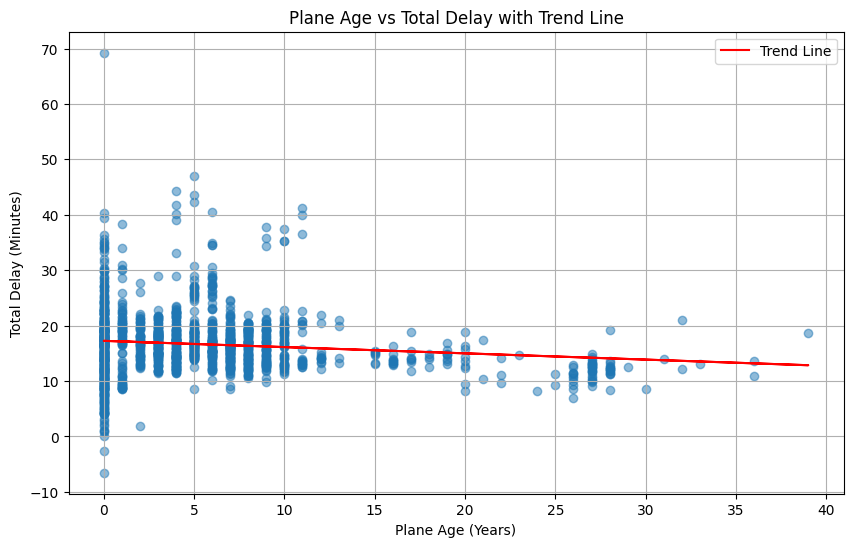

In [91]:

# Assuming your dataframe is called plane_summary_df
plt.figure(figsize=(10, 6))

# Scatter plot of plane_age vs total_delay
plt.scatter(plane_summary_df['plane_age'], plane_summary_df['total_delay'], alpha=0.5)

# Perform linear regression to get the trend line
slope, intercept, _, _, _ = linregress(plane_summary_df['plane_age'], plane_summary_df['total_delay'])

# Generate the trend line
trend_line = slope * plane_summary_df['plane_age'] + intercept

# Plot the trend line
plt.plot(plane_summary_df['plane_age'], trend_line, color='red', label='Trend Line')

# Adding labels and title
plt.xlabel('Plane Age (Years)')
plt.ylabel('Total Delay (Minutes)')
plt.title('Plane Age vs Total Delay with Trend Line')

# Show the plot
plt.grid(True)
plt.legend()
plt.show()



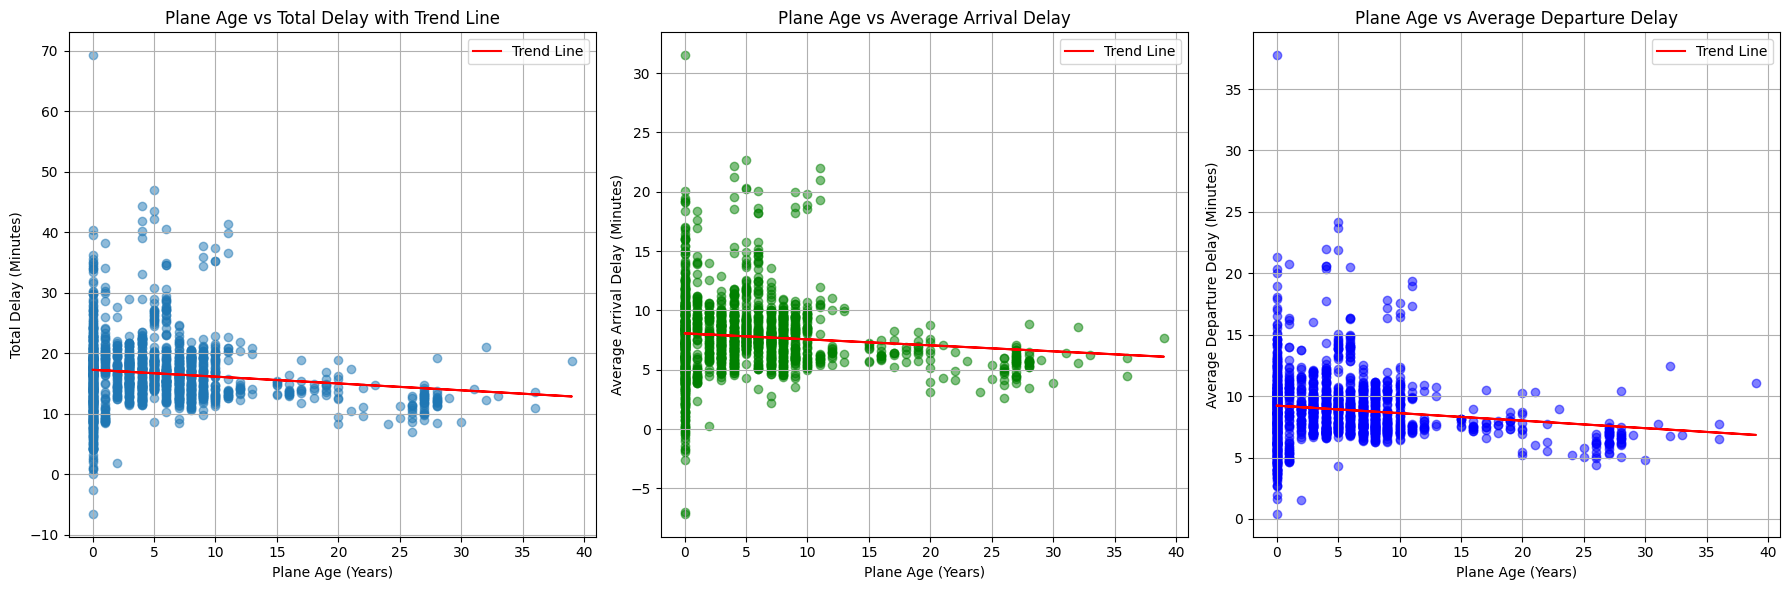

In [93]:


# Create a figure with three subplots: one for the original scatter plot and two for the new scatter plots
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Scatter plot of plane_age vs total_delay
ax[0].scatter(plane_summary_df['plane_age'], plane_summary_df['total_delay'], alpha=0.5)

# Perform linear regression to get the trend line
slope, intercept, _, _, _ = linregress(plane_summary_df['plane_age'], plane_summary_df['total_delay'])

# Generate the trend line
trend_line = slope * plane_summary_df['plane_age'] + intercept

# Plot the trend line
ax[0].plot(plane_summary_df['plane_age'], trend_line, color='red', label='Trend Line')

# Adding labels and title for scatter plot
ax[0].set_xlabel('Plane Age (Years)')
ax[0].set_ylabel('Total Delay (Minutes)')
ax[0].set_title('Plane Age vs Total Delay with Trend Line')
ax[0].grid(True)
ax[0].legend()

# Scatter plot of plane_age vs average_arrdelay
ax[1].scatter(plane_summary_df['plane_age'], plane_summary_df['average_arrdelay'], alpha=0.5, color='green')

# Perform linear regression for plane_age vs average_arrdelay
slope_arr, intercept_arr, _, _, _ = linregress(plane_summary_df['plane_age'], plane_summary_df['average_arrdelay'])

# Generate the trend line for plane_age vs average_arrdelay
trend_line_arr = slope_arr * plane_summary_df['plane_age'] + intercept_arr

# Plot the trend line for plane_age vs average_arrdelay
ax[1].plot(plane_summary_df['plane_age'], trend_line_arr, color='red', label='Trend Line')

# Adding labels and title for plane_age vs average_arrdelay
ax[1].set_xlabel('Plane Age (Years)')
ax[1].set_ylabel('Average Arrival Delay (Minutes)')
ax[1].set_title('Plane Age vs Average Arrival Delay')
ax[1].grid(True)
ax[1].legend()

# Scatter plot of plane_age vs average_depdelay
ax[2].scatter(plane_summary_df['plane_age'], plane_summary_df['average_depdelay'], alpha=0.5, color='blue')

# Perform linear regression for plane_age vs average_depdelay
slope_dep, intercept_dep, _, _, _ = linregress(plane_summary_df['plane_age'], plane_summary_df['average_depdelay'])

# Generate the trend line for plane_age vs average_depdelay
trend_line_dep = slope_dep * plane_summary_df['plane_age'] + intercept_dep

# Plot the trend line for plane_age vs average_depdelay
ax[2].plot(plane_summary_df['plane_age'], trend_line_dep, color='red', label='Trend Line')

# Adding labels and title for plane_age vs average_depdelay
ax[2].set_xlabel('Plane Age (Years)')
ax[2].set_ylabel('Average Departure Delay (Minutes)')
ax[2].set_title('Plane Age vs Average Departure Delay')
ax[2].grid(True)
ax[2].legend()

# Show the plots
plt.tight_layout()
plt.show()


As age increases, average total delay, arrival delay and departure delay (in minutes) decreases, showing a negative linear correlation.

# Pearson correlation plot

In [79]:
from scipy.stats import pearsonr

# Part 2(c)

In [8]:
print(main_df.columns)

Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime',
       'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum',
       'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay',
       'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')


In [9]:
main_df['Diverted'] = main_df['Diverted'].astype('category')

carriers_df = pd.read_csv('carriers.csv')
# Creating a numerical index for carriers
carriers_df['code_n'] = carriers_df.index.astype(int)

regression_main_df = pd.merge(main_df, carriers_df, left_on='UniqueCarrier', right_on='Code', suffixes=('main_df', '_carriers_df'))
regression_main_df = regression_main_df[['Year', 'Month', 'DayOfWeek', 'DepTime', 'CRSDepTime', 'CRSArrTime', 'Distance', 'CRSElapsedTime', 'code_n', 'Diverted']]
regression_main_df = regression_main_df.dropna()

print(regression_main_df.head())

   Year  Month  DayOfWeek  DepTime  CRSDepTime  CRSArrTime  Distance  \
0  1995      1          5    657.0         645         937     678.0   
1  1995      1          6    648.0         645         937     678.0   
2  1995      1          7    649.0         645         937     678.0   
3  1995      1          1    645.0         645         937     678.0   
4  1995      1          2    645.0         645         937     678.0   

   CRSElapsedTime  code_n Diverted  
0           112.0    1297        0  
1           112.0    1297        0  
2           112.0    1297        0  
3           112.0    1297        0  
4           112.0    1297        0  


In [10]:
# Check the unique values of 'Diverted'
print(regression_main_df['Diverted'].unique())

# Ensure everything is binary
regression_main_df['Diverted'] = regression_main_df['Diverted'].astype(int)  # Convert to integer type if not already

# Check again to verify that 'Diverted' contains only binary values
print(regression_main_df['Diverted'].unique())

[0, 1]
Categories (2, int64): [0, 1]
[0 1]


In [12]:
#Checking for diverted in whole data frame
diverted_count = (regression_main_df['Diverted'] == 1).sum()
total_rows = len(regression_main_df)
percentage_diverted = (diverted_count / total_rows) * 100
print(percentage_diverted)

0.2336710710185143


About 23.8% of our dataset is diverted flights.

# Assumption test

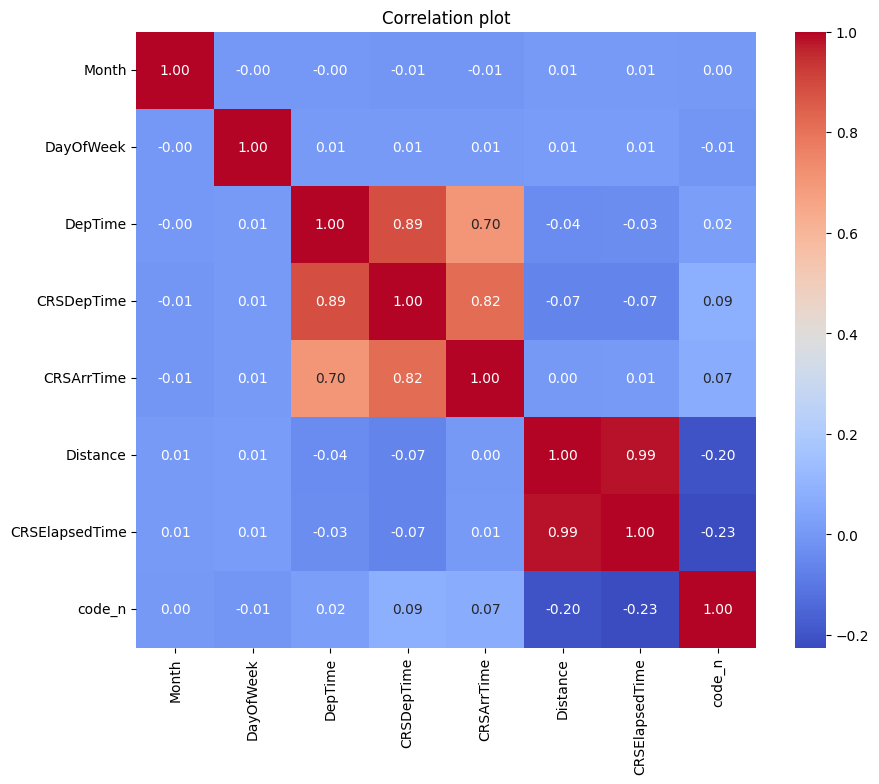

In [13]:
selected_variables = ['Month', 'DayOfWeek', 'DepTime', 'CRSDepTime', 'CRSArrTime', 'Distance', 'CRSElapsedTime', 'code_n']

# Creating the correlation matrix
correlation_matrix = regression_main_df[selected_variables].corr()

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation plot')
plt.show()

Since there is no pairwise correlation of 1, assumption of no perfect multicollinerity is satisfied.

# Sampling using stratified split method

In [16]:
# Seed set for reproducability 
np.random.seed(321)

# Generate random indices for the sample data frame
sample_ratio = 0.2
X = regression_main_df.drop(columns=['Diverted'])  #only contains independent variables 
y = regression_main_df['Diverted']  # only contains diverted

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=sample_ratio, stratify=y) #strat split function

# Create a DataFrame for 20% sample
sample_manifest_df = pd.DataFrame(X_train, columns=X.columns)
sample_manifest_df['Diverted'] = y_train

# checking for diverted in sample_manifest_df
print(sample_manifest_df['Diverted'].value_counts())

NameError: name 'train_test_split' is not defined